# Mall Sales & Customer Analysis — 2025


This project analyzes mall sales and customer purchasing behavior using:
**Python, NumPy, Pandas, Statistics, SQL/SQLite, Matplotlib and Seaborn.**



# Project Roadmap
Professional workflow: data preparation → exploratory analysis → SQL business questions → statistics → dashboard data → business insights.



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import statistics as stats
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load CSV

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

Saving mall_sales_2025_customer_analysis_8000_fixed_gender-1_full_data.csv to mall_sales_2025_customer_analysis_8000_fixed_gender-1_full_data.csv


,Transaction_ID,Date,Customer_Name,Customer_ID,Category,Subcategory,Product,Customer_Age,Age Group,Gender,Membership,Payment_Method,Sales_Channel,Quantity,Unit_Price,Discount_Percent,Discount_Amount,Net_Sales,Tax_Amount,Total_Amount,Cost,Profit,Month,Month Name
0,1,2025-03-12,Neha Gupta,CUST02137,Grocery,Staples,Rice,39,Adult,Male,Regular,Debit Card,In-Store,1,61.70,10,6.17,55.53,10.00,65.53,40.23,15.30,3,Mar
1,2,2025-02-04,Riya Mishra,CUST00195,Electronics,Audio,Headphones,32,Adult,Female,Regular,Wallet,In-Store,2,6595.73,15,1978.72,11212.74,2018.29,13231.03,9001.40,2211.34,2,Feb
2,3,2025-05-23,Riya Kumar,CUST00146,Home & Kitchen,Kitchen,Cookware,40,Adult,Male,Regular,Cash,In-Store,5,2652.79,5,663.20,12600.75,2268.13,14868.88,7679.03,4921.72,5,May
3,4,2025-05-02,Rahul Sharma,CUST01729,Grocery,Staples,Rice,20,Tennager,Female,Regular,Wallet,Online,3,112.07,0,0.00,336.21,60.52,396.73,264.70,71.51,5,May
4,5,2025-11-13,Sneha Tiwari,CUST00459,Grocery,Snacks,Snacks,34,Adult,Female,Regular,Credit Card,In-Store,1,49.13,25,12.28,36.85,6.63,43.48,26.06,10.79,11,Nov


## 3. Data Understanding

In [5]:
print(df.info())
print("\nMissing values:")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    8000 non-null   int64  
 1   Date              8000 non-null   object 
 2   Customer_Name     8000 non-null   object 
 3   Customer_ID       8000 non-null   object 
 4   Category          8000 non-null   object 
 5   Subcategory       8000 non-null   object 
 6   Product           8000 non-null   object 
 7   Customer_Age      8000 non-null   int64  
 8   Age Group         8000 non-null   object 
 9   Gender            8000 non-null   object 
 10  Membership        8000 non-null   object 
 11  Payment_Method    8000 non-null   object 
 12  Sales_Channel     8000 non-null   object 
 13  Quantity          8000 non-null   int64  
 14  Unit_Price        8000 non-null   float64
 15  Discount_Percent  8000 non-null   int64  
 16  Discount_Amount   8000 non-null   float64


In [4]:
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Transaction_ID      0
Date                0
Customer_Name       0
Customer_ID         0
Category            0
Subcategory         0
Product             0
Customer_Age        0
Age Group           0
Gender              0
Membership          0
Payment_Method      0
Sales_Channel       0
Quantity            0
Unit_Price          0
Discount_Percent    0
Discount_Amount     0
Net_Sales           0
Tax_Amount          0
Total_Amount        0
Cost                0
Profit              0
Month               0
Month Name          0
dtype: int64

Duplicate rows: 0


## 4. Data Cleaning

In [6]:
df = df.drop_duplicates().copy()

numeric_cols = [
    "Quantity","Unit_Price","Discount_Percent",
    "Discount_Amount","Net_Sales","Tax_Amount",
    "Total_Amount","Cost","Profit"
]

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

df["Date"] = pd.to_datetime(df["Date"])

print("Cleaned Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())


Cleaned Shape: (8000, 24)
Total Missing Values: 0


## 5. Create Useful Date Columns

In [7]:
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_Name"] = df["Date"].dt.day_name()

df[["Date","Month","Month_Name","Day_Name"]].head()


,Date,Month,Month_Name,Day_Name
0,2025-03-12,3,March,Wednesday
1,2025-02-04,2,February,Tuesday
2,2025-05-23,5,May,Friday
3,2025-05-02,5,May,Friday
4,2025-11-13,11,November,Thursday


## 6. NumPy Analysis

In [8]:
sales_array = df["Net_Sales"].to_numpy()

print("Total Sales:", np.sum(sales_array))
print("Average Sale:", np.mean(sales_array))
print("Minimum Sale:", np.min(sales_array))
print("Maximum Sale:", np.max(sales_array))
print("Sales Standard Deviation:", np.std(sales_array))


Total Sales: 106938020.28
Average Sale: 13367.252535
Minimum Sale: 24.71
Maximum Sale: 510286.25
Sales Standard Deviation: 37320.49454016939


## 7. Pandas Descriptive Statistics

In [9]:
df.describe()


,Transaction_ID,Date,Customer_Age,Quantity,Unit_Price,Discount_Percent,Discount_Amount,Net_Sales,Tax_Amount,Total_Amount,Cost,Profit,Month
count,8000.00000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,2025-07-01 10:40:04.800000,39.104625,1.829875,8122.045721,10.095625,1492.509378,13367.252535,2406.105431,15773.357966,9125.106594,4242.145941,6.508750
min,1.00000,2025-01-01 00:00:00,18.000000,1.000000,31.030000,0.000000,0.000000,24.710000,4.450000,29.160000,18.060000,4.710000,1.000000
25%,2000.75000,2025-03-31 00:00:00,28.000000,1.000000,493.115000,5.000000,3.227500,722.812500,130.102500,852.915000,489.110000,210.025000,3.000000
50%,4000.50000,2025-07-02 00:00:00,39.000000,1.000000,1893.765000,10.000000,144.295000,2465.855000,443.855000,2909.710000,1659.955000,743.720000,7.000000
75%,6000.25000,2025-10-01 06:00:00,50.000000,2.000000,4068.415000,15.000000,626.475000,6340.700000,1141.327500,7482.027500,4362.575000,1987.490000,10.000000
max,8000.00000,2025-12-30 00:00:00,60.000000,5.000000,119664.000000,25.000000,87835.700000,510286.250000,91851.520000,602137.770000,400548.900000,177462.360000,12.000000
std,2309.54541,NaN,12.492375,1.136153,19160.364907,8.206470,5430.584741,37322.827290,6718.108929,44040.936218,25801.694332,12142.100724,3.435098


## 8. Statistics Module

In [10]:
sales_list = df["Net_Sales"].tolist()

print("Mean:", round(stats.mean(sales_list), 2))
print("Median:", round(stats.median(sales_list), 2))
print("Mode of Month:", stats.mode(df["Month"].tolist()))


Mean: 13367.25
Median: 2465.86
Mode of Month: 10


## 9. Main Business KPIs

In [11]:
total_sales = df["Net_Sales"].sum()
total_profit = df["Profit"].sum()
total_units = df["Quantity"].sum()
avg_order_value = df["Total_Amount"].mean()

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Profit Margin: {(total_profit/total_sales)*100:.2f}%")


Total Sales: ₹106,938,020.28
Total Profit: ₹33,937,167.53
Total Units Sold: 14,639
Average Order Value: ₹15,773.36
Profit Margin: 31.74%


## 10. Category-wise Sales

In [12]:
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Net_Sales","sum"),
          Total_Profit=("Profit","sum"),
          Units_Sold=("Quantity","sum"),
          Transactions=("Transaction_ID","count")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_summary


,Total_Sales,Total_Profit,Units_Sold,Transactions
Category,,,,
Electronics,83995334.84,26614180.38,2391,1307
Home & Kitchen,8007077.77,2582947.77,2157,1163
Fashion,7366000.27,2340276.24,3223,1809
Beauty,4074579.92,1287084.64,2077,1100
Sports,2528964.40,807180.49,833,484
Grocery,966063.08,305498.01,3958,2137


## 11. Subcategory-wise Sales — Highest

In [13]:
subcategory_summary = (
    df.groupby(["Category","Subcategory"])
      .agg(
          Total_Sales=("Net_Sales","sum"),
          Units_Sold=("Quantity","sum"),
          Transactions=("Transaction_ID","count")
      )
      .sort_values("Total_Sales", ascending=False)
)

subcategory_summary.head(10)


Total_Sales  Units_Sold  Transactions
Category       Subcategory                                                
Electronics    Computers             34167385.58         467           263
               Mobile & Accessories  28193947.15         753           400
               Television            17633416.16         309           163
               Audio                  4000585.95         862           481
Fashion        Footwear               3411614.18        1000           555
Home & Kitchen Furniture              3240640.42         194           101
Fashion        Men's Clothing         2767937.26        1934          1088
Sports         Fitness                2528964.40         833           484
Beauty         Makeup                 1742389.17         915           491
Home & Kitchen Appliances             1741669.07         488           252

## 12. Subcategory-wise Sales — Lowest

In [14]:
subcategory_summary.sort_values(
    "Total_Sales", ascending=True
).head(10)


Total_Sales  Units_Sold  Transactions
Category       Subcategory                                         
Grocery        Staples           72760.49         968           522
               Beverages        141661.34        1130           589
               Snacks           319557.47        1282           706
               Personal Care    432083.78         578           320
Beauty         Fragrance       1141714.24         465           243
Fashion        Winter Wear     1186448.83         289           166
Beauty         Skincare        1190476.51         697           366
Home & Kitchen Bedroom         1394735.78         778           430
               Kitchen         1630032.50         697           380
               Appliances      1741669.07         488           252

## 13. Highest-selling Product

In [15]:
product_summary = (
    df.groupby("Product")
      .agg(
          Total_Sales=("Net_Sales","sum"),
          Units_Sold=("Quantity","sum"),
          Profit=("Profit","sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("Highest-selling product:")
display(product_summary.head(10))


Highest-selling product:


,Total_Sales,Units_Sold,Profit
Product,,,
Laptop,34167385.58,467,10850866.78
Smartphone,28193947.15,753,8827506.69
Smart TV,17633416.16,309,5684382.16
Headphones,4000585.95,862,1251424.75
Shoes,3411614.18,1000,1091974.77
Furniture,3240640.42,194,1064766.42
Fitness Gear,2528964.40,833,807180.49
Makeup,1742389.17,915,550738.29
Mixer Grinder,1741669.07,488,569001.91


## 14. Lowest-selling Product

In [16]:
print("Lowest-selling products:")
display(product_summary.sort_values("Total_Sales").head(10))


Lowest-selling products:


,Total_Sales,Units_Sold,Profit
Product,,,
Rice,72760.49,968,22390.00
Beverages,141661.34,1130,44297.41
Snacks,319557.47,1282,102595.52
Personal Care,432083.78,578,136215.08
T-Shirt,1089232.21,1099,339088.63
Perfume,1141714.24,465,360770.04
Jacket,1186448.83,289,369874.45
Skincare,1190476.51,697,375576.31
Bedsheet,1394735.78,778,427430.02


## 15. Customer-wise Purchase Analysis

In [17]:
customer_summary = (
    df.groupby(["Customer_ID","Customer_Name"])
      .agg(
          Total_Sales=("Net_Sales","sum"),
          Total_Orders=("Transaction_ID","count"),
          Total_Units=("Quantity","sum"),
          Total_Profit=("Profit","sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

customer_summary.head(10)


,,Total_Sales,Total_Orders,Total_Units,Total_Profit
Customer_ID,Customer_Name,,,,
CUST00059,Amit Jain,973346.39,79,156,310221.26
CUST00088,Priya Das,839934.51,57,84,285641.04
CUST00049,Aarav Jain,785455.05,34,64,266727.66
CUST00048,Karan Roy,765579.19,26,57,217083.16
CUST00064,Aditya Sharma,710930.32,70,117,257098.79
CUST01858,Neha Tiwari,671531.71,13,23,212684.71
CUST02022,Arjun Das,647565.83,15,25,186930.27
CUST00030,Aditya Chauhan,596156.83,12,31,154805.43
CUST00928,Amit Tiwari,570495.05,8,18,125097.48


## 16. Top Customers by Purchase Amount

In [18]:
top_customers = customer_summary.head(10)

print("Top 10 customers by purchase amount:")
display(top_customers)


Top 10 customers by purchase amount:


,,Total_Sales,Total_Orders,Total_Units,Total_Profit
Customer_ID,Customer_Name,,,,
CUST00059,Amit Jain,973346.39,79,156,310221.26
CUST00088,Priya Das,839934.51,57,84,285641.04
CUST00049,Aarav Jain,785455.05,34,64,266727.66
CUST00048,Karan Roy,765579.19,26,57,217083.16
CUST00064,Aditya Sharma,710930.32,70,117,257098.79
CUST01858,Neha Tiwari,671531.71,13,23,212684.71
CUST02022,Arjun Das,647565.83,15,25,186930.27
CUST00030,Aditya Chauhan,596156.83,12,31,154805.43
CUST00928,Amit Tiwari,570495.05,8,18,125097.48


## 17. Monthly Sales — Highest and Lowest

In [19]:
monthly_sales = (
    df.groupby("Month")
      .agg(
          Total_Sales=("Net_Sales","sum"),
          Units_Sold=("Quantity","sum"),
          Transactions=("Transaction_ID","count")
      )
      .sort_index()
)

highest_month = monthly_sales["Total_Sales"].idxmax()
lowest_month = monthly_sales["Total_Sales"].idxmin()

print("Highest-selling month:", highest_month)
print("Lowest-selling month:", lowest_month)

monthly_sales


Highest-selling month: 10
Lowest-selling month: 5


,Total_Sales,Units_Sold,Transactions
Month,,,
1,8322670.62,1194,682
2,8259018.26,1128,622
3,11120124.66,1349,702
4,7704453.96,1203,641
5,7423060.56,1157,629
6,9563895.14,1256,679
7,7476888.18,1222,690
8,8817917.19,1302,694
9,8785609.47,1181,645


## 18. Age Group Analysis

In [20]:
df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=[17,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","56+"]
)

age_summary = (
    df.groupby("Age_Group", observed=False)
      .agg(
          Customers=("Customer_ID","nunique"),
          Orders=("Transaction_ID","count"),
          Sales=("Net_Sales","sum")
      )
)

age_summary


,Customers,Orders,Sales
Age_Group,,,
18-25,886,1499,21412231.77
26-35,1001,1832,23992879.20
36-45,981,1823,23768768.15
46-55,1009,1904,26177680.43
56+,643,942,11586460.73


## 19. Which Age Group Shops the Most?

In [21]:
best_age_group = age_summary["Orders"].idxmax()

print("Age group with most shopping activity:", best_age_group)
print("Orders:", age_summary.loc[best_age_group, "Orders"])


Age group with most shopping activity: 46-55
Orders: 1904


## 20. Age Group with Most Memberships

In [22]:
membership_by_age = pd.crosstab(
    df["Age_Group"],
    df["Membership"]
)

membership_by_age["Total_Memberships"] = membership_by_age.sum(axis=1)

print("Memberships by age group:")
display(membership_by_age)

print(
    "Age group with most memberships:",
    membership_by_age["Total_Memberships"].idxmax()
)


Memberships by age group:


Membership,Gold,Platinum,Regular,Silver,Total_Memberships
Age_Group,,,,,
18-25,262,121,772,344,1499
26-35,352,159,952,369,1832
36-45,367,151,918,387,1823
46-55,378,149,938,439,1904
56+,185,82,486,189,942


Age group with most memberships: 46-55


## 21. Repeated Customers

In [23]:
customer_frequency = (
    df.groupby(["Customer_ID","Customer_Name"])
      .size()
      .reset_index(name="Purchase_Count")
)

repeated_customers = customer_frequency[
    customer_frequency["Purchase_Count"] > 1
]

print("Total unique customers:", customer_frequency["Customer_ID"].nunique())
print("Customers who purchased repeatedly:", len(repeated_customers))
print(
    "Repeat customer percentage:",
    round(len(repeated_customers) /
          len(customer_frequency) * 100, 2),
    "%"
)

repeated_customers.sort_values(
    "Purchase_Count", ascending=False
).head(10)


Total unique customers: 1827
Customers who purchased repeatedly: 1366
Repeat customer percentage: 74.77 %


,Customer_ID,Customer_Name,Purchase_Count
53,CUST00059,Amit Jain,79
58,CUST00064,Aditya Sharma,70
79,CUST00088,Priya Das,57
47,CUST00052,Simran Sinha,47
91,CUST00100,Vikash Gupta,47
122,CUST00133,Aarav Mehta,39
136,CUST00149,Nisha Mehta,38
101,CUST00111,Aarav Kumar,38
44,CUST00049,Aarav Jain,34
92,CUST00101,Simran Chauhan,33


## 22. Customer Purchase Frequency

In [24]:
frequency_distribution = (
    customer_frequency["Purchase_Count"]
    .value_counts()
    .sort_index()
)

frequency_distribution


,count
Purchase_Count,
1,461
2,358
3,247
4,179
5,140
6,104
7,76
8,50
9,44


## 23. Membership Analysis

In [25]:
membership_summary = (
    df.groupby("Membership")
      .agg(
          Customers=("Customer_ID","nunique"),
          Orders=("Transaction_ID","count"),
          Sales=("Net_Sales","sum")
      )
      .sort_values("Sales", ascending=False)
)

membership_summary


,Customers,Orders,Sales
Membership,,,
Regular,1469,4066,54202758.42
Silver,967,1728,22970563.50
Gold,879,1544,20105202.92
Platinum,504,662,9659495.44


## 24. Payment Method Analysis

In [26]:
payment_summary = (
    df.groupby("Payment_Method")
      .agg(
          Sales=("Net_Sales","sum"),
          Orders=("Transaction_ID","count")
      )
      .sort_values("Sales", ascending=False)
)

payment_summary


,Sales,Orders
Payment_Method,,
Wallet,23196351.02,1617
UPI,21893219.17,1633
Debit Card,21773265.43,1588
Credit Card,21168659.64,1589
Cash,18906525.02,1573


## 25. SQL Database Setup

In [27]:
conn = sqlite3.connect(":memory:")

df.to_sql(
    "mall_sales",
    conn,
    index=False,
    if_exists="replace"
)

print("SQL table created successfully.")


SQL table created successfully.


## 26. SQL — Top Customers

In [28]:
query = '''
SELECT
    Customer_ID,
    Customer_Name,
    ROUND(SUM(Net_Sales),2) AS Total_Purchase,
    COUNT(Transaction_ID) AS Purchase_Count
FROM mall_sales
GROUP BY Customer_ID, Customer_Name
ORDER BY Total_Purchase DESC
LIMIT 10;
'''

pd.read_sql_query(query, conn)


,Customer_ID,Customer_Name,Total_Purchase,Purchase_Count
0,CUST00059,Amit Jain,973346.39,79
1,CUST00088,Priya Das,839934.51,57
2,CUST00049,Aarav Jain,785455.05,34
3,CUST00048,Karan Roy,765579.19,26
4,CUST00064,Aditya Sharma,710930.32,70
5,CUST01858,Neha Tiwari,671531.71,13
6,CUST02022,Arjun Das,647565.83,15
7,CUST00030,Aditya Chauhan,596156.83,12
8,CUST00928,Amit Tiwari,570495.05,8
9,CUST00026,Vivaan Gupta,561958.92,7


## 27. SQL — Highest Subcategory

In [29]:
query = '''
SELECT
    Category,
    Subcategory,
    ROUND(SUM(Net_Sales),2) AS Total_Sales
FROM mall_sales
GROUP BY Category, Subcategory
ORDER BY Total_Sales DESC;
'''

pd.read_sql_query(query, conn)


,Category,Subcategory,Total_Sales
0,Electronics,Computers,34167385.58
1,Electronics,Mobile & Accessories,28193947.15
2,Electronics,Television,17633416.16
3,Electronics,Audio,4000585.95
4,Fashion,Footwear,3411614.18
5,Home & Kitchen,Furniture,3240640.42
6,Fashion,Men's Clothing,2767937.26
7,Sports,Fitness,2528964.40
8,Beauty,Makeup,1742389.17
9,Home & Kitchen,Appliances,1741669.07


## 28. SQL — Lowest Subcategory

In [30]:
query = '''
SELECT
    Category,
    Subcategory,
    ROUND(SUM(Net_Sales),2) AS Total_Sales
FROM mall_sales
GROUP BY Category, Subcategory
ORDER BY Total_Sales ASC;
'''

pd.read_sql_query(query, conn).head(10)


,Category,Subcategory,Total_Sales
0,Grocery,Staples,72760.49
1,Grocery,Beverages,141661.34
2,Grocery,Snacks,319557.47
3,Grocery,Personal Care,432083.78
4,Beauty,Fragrance,1141714.24
5,Fashion,Winter Wear,1186448.83
6,Beauty,Skincare,1190476.51
7,Home & Kitchen,Bedroom,1394735.78
8,Home & Kitchen,Kitchen,1630032.50
9,Home & Kitchen,Appliances,1741669.07


## 29. SQL — Repeated Customers

In [31]:
query = '''
SELECT
    Customer_ID,
    Customer_Name,
    COUNT(*) AS Purchase_Count
FROM mall_sales
GROUP BY Customer_ID, Customer_Name
HAVING COUNT(*) > 1
ORDER BY Purchase_Count DESC;
'''

repeat_sql = pd.read_sql_query(query, conn)

print("Number of repeated customers:", len(repeat_sql))
repeat_sql.head(10)


Number of repeated customers: 1366


,Customer_ID,Customer_Name,Purchase_Count
0,CUST00059,Amit Jain,79
1,CUST00064,Aditya Sharma,70
2,CUST00088,Priya Das,57
3,CUST00052,Simran Sinha,47
4,CUST00100,Vikash Gupta,47
5,CUST00133,Aarav Mehta,39
6,CUST00111,Aarav Kumar,38
7,CUST00149,Nisha Mehta,38
8,CUST00049,Aarav Jain,34
9,CUST00101,Simran Chauhan,33


## 30. Matplotlib — Monthly Sales

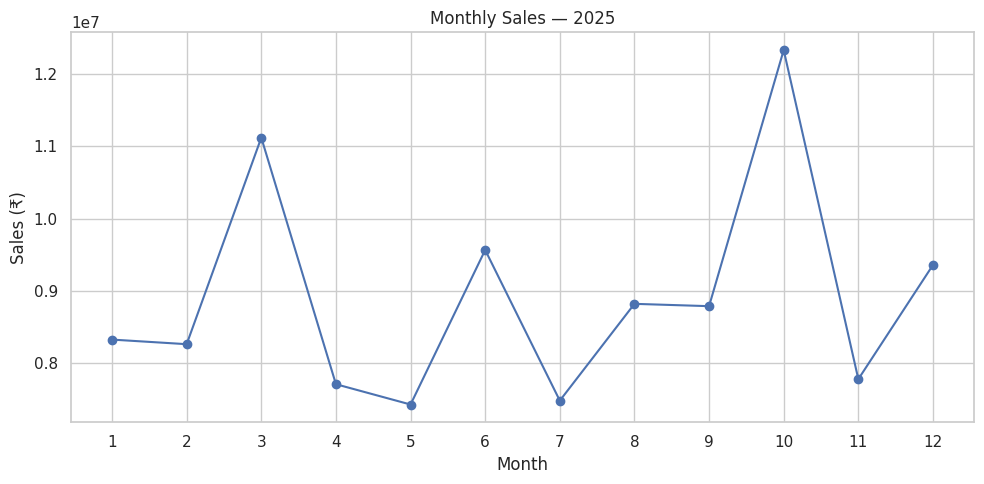

In [32]:
plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales.index,
    monthly_sales["Total_Sales"],
    marker="o"
)
plt.title("Monthly Sales — 2025")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()


## 31. Seaborn — Subcategory Sales

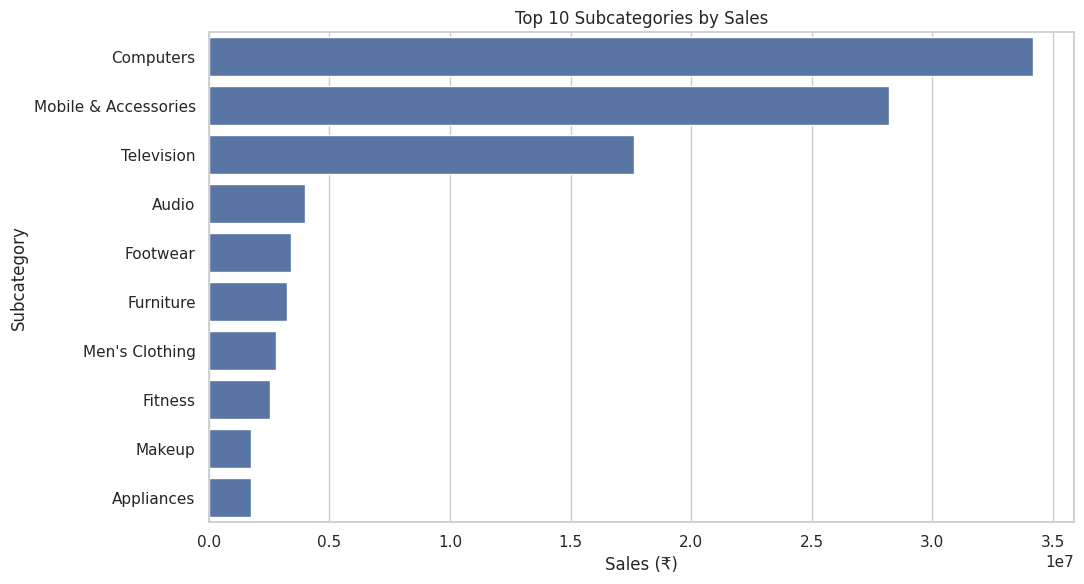

In [33]:
plot_data = (
    subcategory_summary
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))
sns.barplot(
    data=plot_data,
    x="Total_Sales",
    y="Subcategory"
)
plt.title("Top 10 Subcategories by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()


## 32. Seaborn — Age Group Shopping

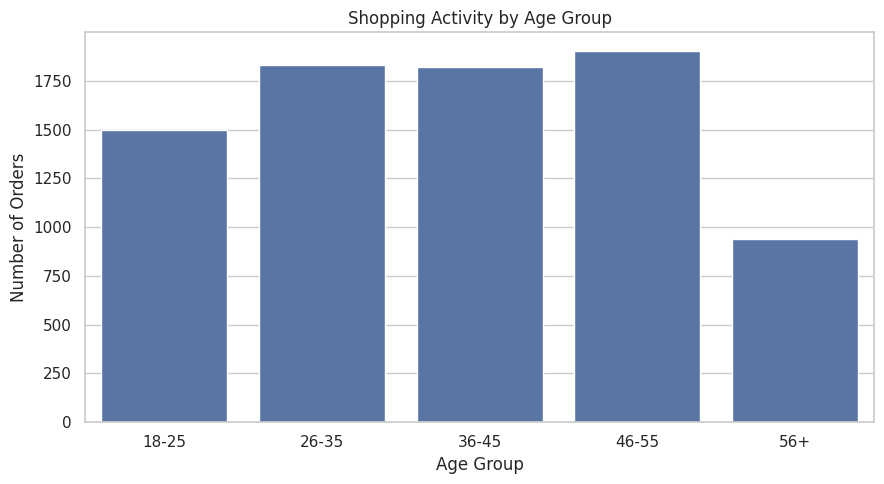

In [34]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=age_summary.reset_index(),
    x="Age_Group",
    y="Orders"
)
plt.title("Shopping Activity by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


## 33. Seaborn — Membership by Age

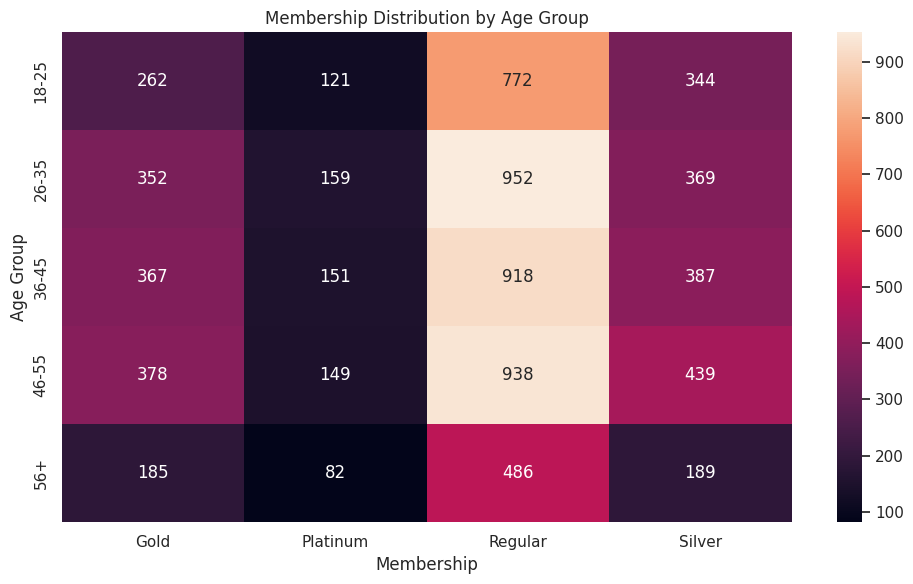

In [35]:
membership_plot = pd.crosstab(
    df["Age_Group"],
    df["Membership"]
)

plt.figure(figsize=(10,6))
sns.heatmap(
    membership_plot,
    annot=True,
    fmt="d"
)
plt.title("Membership Distribution by Age Group")
plt.xlabel("Membership")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()


## 34. Seaborn — Sales Distribution

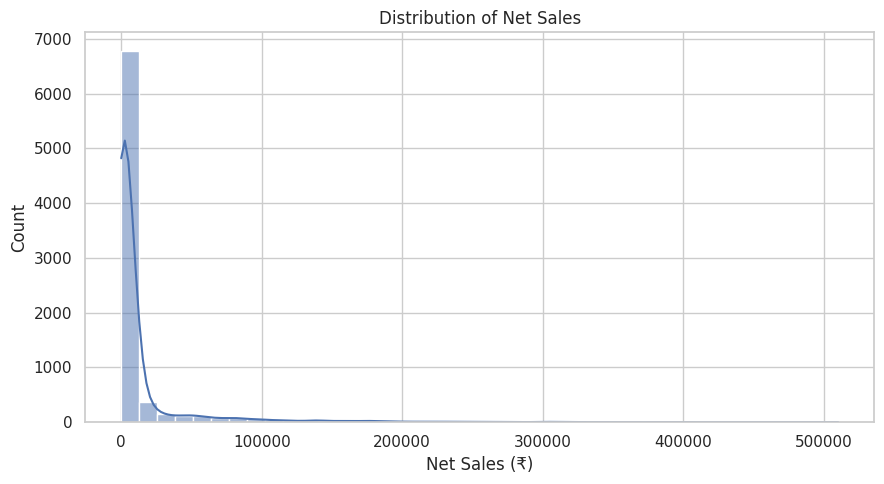

In [36]:
plt.figure(figsize=(9,5))
sns.histplot(
    df["Net_Sales"],
    bins=40,
    kde=True
)
plt.title("Distribution of Net Sales")
plt.xlabel("Net Sales (₹)")
plt.tight_layout()
plt.show()


## 35. Correlation Analysis

In [37]:
corr_cols = [
    "Customer_Age","Quantity","Unit_Price",
    "Discount_Percent","Net_Sales","Total_Amount",
    "Cost","Profit"
]

correlation = df[corr_cols].corr()
correlation


,Customer_Age,Quantity,Unit_Price,Discount_Percent,Net_Sales,Total_Amount,Cost,Profit
Customer_Age,1.000000,0.029608,-0.030786,-0.014469,-0.008810,-0.008810,-0.009771,-0.006317
Quantity,0.029608,1.000000,-0.000118,0.006706,0.209304,0.209304,0.207830,0.201733
Unit_Price,-0.030786,-0.000118,1.000000,-0.008107,0.837212,0.837212,0.827500,0.815032
Discount_Percent,-0.014469,0.006706,-0.008107,1.000000,-0.035357,-0.035357,-0.035926,-0.032342
Net_Sales,-0.008810,0.209304,0.837212,-0.035357,1.000000,1.000000,0.992371,0.965071
Total_Amount,-0.008810,0.209304,0.837212,-0.035357,1.000000,1.000000,0.992371,0.965071
Cost,-0.009771,0.207830,0.827500,-0.035926,0.992371,0.992371,1.000000,0.925407
Profit,-0.006317,0.201733,0.815032,-0.032342,0.965071,0.965071,0.925407,1.000000


## 36. Seaborn — Correlation Heatmap

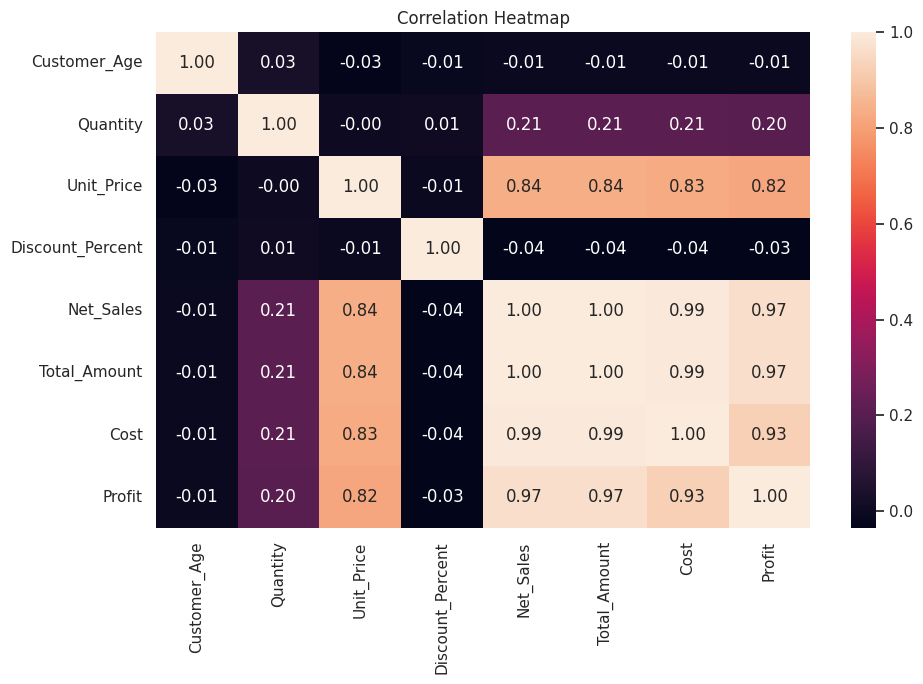

In [38]:
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 37. Final Business Insights

In [39]:
print("========== FINAL BUSINESS INSIGHTS ==========")
print("Highest-selling category:",
      category_summary["Total_Sales"].idxmax())

print("Highest-selling subcategory:",
      subcategory_summary["Total_Sales"].idxmax())

print("Lowest-selling subcategory:",
      subcategory_summary["Total_Sales"].idxmin())

print("Top customer:",
      customer_summary.index[0])

print("Highest-selling month:",
      highest_month)

print("Lowest-selling month:",
      lowest_month)

print("Most active age group:",
      best_age_group)

print("Age group with most memberships:",
      membership_by_age["Total_Memberships"].idxmax())

print("Repeated customers:",
      len(repeated_customers))

print(f"Total sales: ₹{total_sales:,.2f}")
print(f"Total profit: ₹{total_profit:,.2f}")


========== FINAL BUSINESS INSIGHTS ==========
Highest-selling category: Electronics
Highest-selling subcategory: ('Electronics', 'Computers')
Lowest-selling subcategory: ('Grocery', 'Staples')
Top customer: ('CUST00059', 'Amit Jain')
Highest-selling month: 10
Lowest-selling month: 5
Most active age group: 46-55
Age group with most memberships: 46-55
Repeated customers: 1366
Total sales: ₹106,938,020.28
Total profit: ₹33,937,167.53


# 38. Final Export

In [ ]:
# Cleaned data ko CSV file mein save karo
df.to_csv("mall_sales_2025_cleaned.csv", index=False)

# CSV file download karo
from google.colab import files
files.download("mall_sales_2025_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This  project focuses on **customer and product-level mall sales analysis**.

It answers questions such as:

1. Which category/subcategory sold the most?
2. Which category/subcategory sold the least?
3. Which customers purchased the most?
4. Which month had the highest sales?
5. Which month had the lowest sales?
6. Which age group shops the most?
7. Which age group has the most memberships?
8. How many customers purchase repeatedly?
9. What is the purchase frequency of customers?
10. Which membership/payment method generates the most sales?
